In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

sys.path.append('..')
from src.utils import standardize, augment_data, augment_data_v2
from src.models import KernelRidgeRegression, KRR_Custom
from src.models import KernelSVM
from src.kernels import rbf_kernel, laplacian_kernel, linear_kernel
from src.features import hog_descriptor, hog_descriptor_v2, color_histogram, spatial_color_histogram

%matplotlib inline

## 0. Data loading and analysis

In [2]:
data_path = '../data/'

df_train= pd.read_csv(os.path.join(data_path, 'Xtr.csv'), header = None)
df_test = pd.read_csv(os.path.join(data_path, 'Xte.csv'), header = None)
y_train_raw = pd.read_csv(os.path.join(data_path, 'Ytr.csv'))

X_train = df_train.iloc[:, :3072].values
X_test = df_test.iloc[:, :3072].values
y_train = y_train_raw.iloc[:, 1].values

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

print(f"Y_train: {y_train_raw.shape}")
print(f"Classes : {np.unique(y_train)}")

print(df_train.head())


X_train: (5000, 3072)
X_test: (2000, 3072)
Y_train: (5000, 2)
Classes : [0 1 2 3 4 5 6 7 8 9]
       0         1         2         3         4         5         6     \
0  0.007018  0.000323  0.002215  0.000781 -0.005636 -0.001525 -0.001090   
1  0.000819  0.001688  0.002698  0.004685  0.011166  0.017482  0.045989   
2 -0.016779  0.006662 -0.007226 -0.003798 -0.004273 -0.009955 -0.030925   
3  0.014936  0.004218  0.009732  0.007309  0.004914  0.008172  0.014205   
4 -0.073091 -0.046800 -0.056235 -0.063619 -0.088387 -0.044682 -0.014172   

       7         8         9     ...      3063      3064      3065      3066  \
0 -0.001907  0.004179 -0.004225  ... -0.002166 -0.005094  0.001906 -0.006143   
1  0.031377  0.032150  0.062066  ...  0.007203  0.008634  0.006800  0.014114   
2 -0.007064  0.008136  0.000618  ... -0.023748  0.047707  0.072310  0.056837   
3 -0.023263 -0.023014  0.011482  ... -0.029634 -0.024069 -0.000788 -0.005010   
4 -0.077535 -0.100056 -0.066161  ... -0.018166  0.01298

In [3]:
def plot_image(X):

    r = X[0:1024].reshape(32, 32)
    g = X[1024:2048].reshape(32, 32)
    b = X[2048:3072].reshape(32, 32)

    img = np.stack([r, g, b], axis=2)

    img = (img - img.min()) / (img.max() - img.min())

    plt.imshow(img)
    plt.axis('off')

    plt.show()

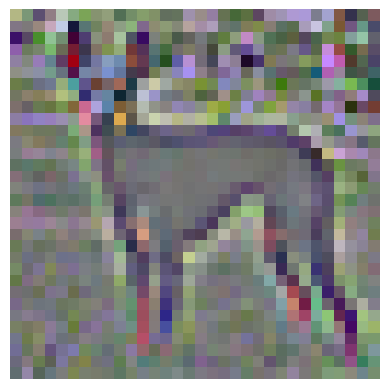

In [5]:
X_train_std, X_test_std = standardize(X_train, X_test)
plot_image(X_train_std[5])


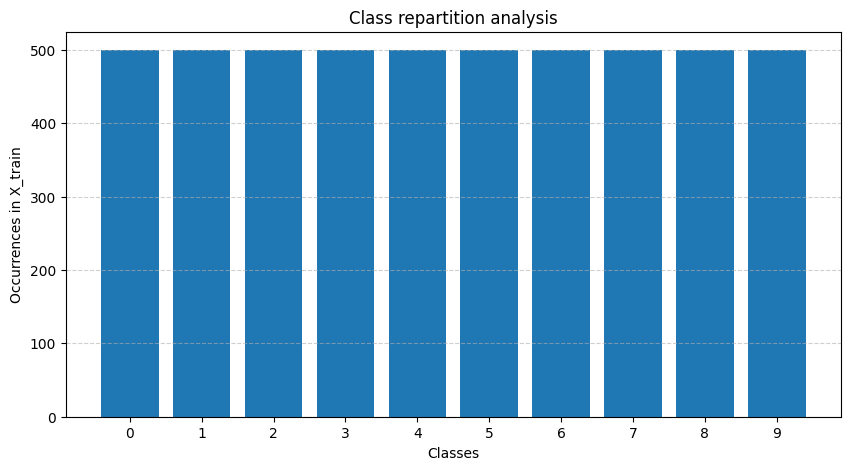

Class 0: 500 samples (10.0%)
Class 1: 500 samples (10.0%)
Class 2: 500 samples (10.0%)
Class 3: 500 samples (10.0%)
Class 4: 500 samples (10.0%)
Class 5: 500 samples (10.0%)
Class 6: 500 samples (10.0%)
Class 7: 500 samples (10.0%)
Class 8: 500 samples (10.0%)
Class 9: 500 samples (10.0%)


In [6]:
classes, counts = np.unique(y_train, return_counts=True)

prop = (counts / len(y_train)) * 100

plt.figure(figsize=(10, 5))
bars = plt.bar(classes, counts)

for i, bar in enumerate(bars):
    yval = bar.get_height()

plt.xlabel('Classes')
plt.ylabel('Occurrences in X_train')
plt.title('Class repartition analysis')
plt.xticks(classes)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

for c, cnt in zip(classes, counts):
    print(f"Class {c}: {cnt} samples ({cnt/len(y_train)*100:.1f}%)")

## 1. Baseline test (Binary Task)
We will try to separate class 0 and 1, using Kernel Ridge Regression and Kernel SVM, on the RBF Kernel 
$$K(x, x') = \exp\left(-\frac{\|x - x'\|^2}{2\sigma^2}\right)$$

In [9]:
idx_0 = np.where(y_train == 0)[0]
idx_1 = np.where(y_train == 1)[0]


X_binary = np.vstack([X_train_std[idx_0], X_train_std[idx_1]])
y_binary = np.hstack([np.ones(len(idx_0)), -np.ones(len(idx_1))])

indices = np.random.permutation(len(y_binary))

X_binary = X_binary[indices]
y_binary = y_binary[indices]

print(f"Binary Datset : {X_binary.shape}, Labels : {np.unique(y_binary)}")

Binary Datset : (1000, 3072), Labels : [-1.  1.]


In [10]:
n_split = 800

X_bin_train = X_binary[:n_split]
y_bin_train = y_binary[:n_split]

X_bin_val = X_binary[n_split:]
y_bin_val = y_binary[n_split:]

print(f"Train size: {X_bin_train.shape[0]} | Val size: {X_bin_val.shape[0]}")

Train size: 800 | Val size: 200


In [11]:
# Guessing sigma value with the Median Trick
def get_median_sigma(X):
    sq_norms = np.sum(X**2, axis=1).reshape(-1, 1)
    dists_sq = sq_norms + sq_norms.T - 2 * np.dot(X, X.T)
    dists_sq = np.maximum(dists_sq, 0)
    dists = np.sqrt(dists_sq)
    
    n = X.shape[0]
    sorted_idx = np.triu_indices(n, k=1)
    
    return np.median(dists[sorted_idx])

sigma_auto = get_median_sigma(X_bin_train)
print(f"Suggested Sigma: {sigma_auto}")

Suggested Sigma: 79.72058687348778


In [12]:
K = rbf_kernel(X_bin_train, X_bin_train, sigma=sigma_auto) # checking for Gram matrix diagonability
print(f"Mean non diagonal value : {np.mean(K[~np.eye(K.shape[0], dtype=bool)])}")

Mean non diagonal value : 0.6080864022950435


In [13]:
model_krr = KernelRidgeRegression(sigma=sigma_auto, lambd=0.005)

print("Training KRR on binary classification...")
model_krr.fit(X_bin_train, y_bin_train)

Training KRR on binary classification...


In [14]:
model_svm = KernelSVM(func=lambda x, y: rbf_kernel(x, y, sigma=sigma_auto), 
                      C=1, 
                      epochs=100)
print("Training Kernel SVM on binary classification...")
model_svm.fit(X_bin_train, y_bin_train)

Training Kernel SVM on binary classification...


In [15]:
naive = np.mean(y_bin_train == -1) # Always predict -1

In [16]:
scores_krr = model_krr.predict(X_bin_val)
y_pred_krr = np.where(scores_krr > 0, 1, -1)
accuracy_krr = np.mean(y_pred_krr == y_bin_val)

scores_svm = model_svm.predict(X_bin_val)
y_pred_svm = np.where(scores_svm > 0, 1, -1)
accuracy_svm = np.mean(y_pred_svm == y_bin_val)

print(f"--- Results ---")
print(f"Accuracy (Naive) : {naive * 100:.2f}%")
print(f"Accuracy (KRR) : {accuracy_krr * 100:.2f}%")
print(f"Accuracy (SVM) : {accuracy_svm * 100:.2f}%")


--- Results ---
Accuracy (Naive) : 48.00%
Accuracy (KRR) : 65.00%
Accuracy (SVM) : 68.50%


### Grid Searching for optimal $\sigma, \lambda, C$.

In [17]:
sigmas = [70, 75, 80, 85, 90, 95, 100, 500, 1000]
lambdas = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 1]
Cs = [0.01, 0.1, 1, 1.5, 2, 2.5, 5, 10]

In [18]:
best_acc_krr = 0
best_params_krr = {}

print("--- Grid Search KRR ---")
for s in sigmas:
    for l in lambdas:
        model = KernelRidgeRegression(sigma=s, lambd=l)
        model.fit(X_bin_train, y_bin_train)
        
        preds = np.where(model.predict(X_bin_val) > 0, 1, -1)
        acc = np.mean(preds == y_bin_val)
        
        if acc > best_acc_krr:
            best_acc_krr = acc
            best_params_krr = {'sigma': s, 'lambda': l}
            
print(f"Best acc (KRR): {best_acc_krr*100:.2f}% with {best_params_krr}")

--- Grid Search KRR ---
Best acc (KRR): 70.00% with {'sigma': 70, 'lambda': 0.001}


In [19]:
best_acc_svm = 0
best_params_svm = {}

print("\n--- Grid Search SVM ---")
for s in sigmas:
    for c in Cs:
        kernel_func = lambda x, y: rbf_kernel(x, y, sigma=s)
        
        model = KernelSVM(func=kernel_func, C=c, epochs=50)
        model.fit(X_bin_train, y_bin_train)
        
        preds = np.where(model.predict(X_bin_val) > 0, 1, -1)
        acc = np.mean(preds == y_bin_val)
        
        if acc > best_acc_svm:
            best_acc_svm = acc
            best_params_svm = {'sigma': s, 'C': c}

print(f"Best acc (SVM): {best_acc_svm*100:.2f}% with {best_params_svm}")


--- Grid Search SVM ---
Best acc (SVM): 72.50% with {'sigma': 70, 'C': 10}


## 3. Baseline + HOG Feature Exaction

In [20]:
print("--- Extracting features (HOG) ---")
X_train_hog = hog_descriptor(X_train)
X_test_hog = hog_descriptor(X_test)

print(f"Hog features : {X_train_hog.shape}")

X_train_hog_std, X_test_hog_std = standardize(X_train_hog, X_test_hog)

--- Extracting features (HOG) ---
Hog features : (5000, 144)


In [21]:
idx_0 = np.where(y_train == 0)[0]
idx_1 = np.where(y_train == 1)[0]

X_binary_hog = np.vstack([X_train_hog_std[idx_0], X_train_hog_std[idx_1]])
y_binary_hog = np.hstack([np.ones(len(idx_0)), -np.ones(len(idx_1))])

indices = np.random.permutation(len(y_binary_hog))
X_binary_hog = X_binary_hog[indices]
y_binary_hog = y_binary_hog[indices]

n_split = 800
X_hog_train, X_hog_val = X_binary_hog[:n_split], X_binary_hog[n_split:]
y_hog_train, y_hog_val = y_binary_hog[:n_split], y_binary_hog[n_split:]

sigma_hog = get_median_sigma(X_hog_train)
print(f"Suggested Sigma (HOG) : {sigma_hog:.2f}")

Suggested Sigma (HOG) : 17.11


In [22]:
print("Training KRR on HOG features...")
model_krr_hog = KernelRidgeRegression(sigma=sigma_hog, lambd=0.005) # Hyperparamètres à tuner
model_krr_hog.fit(X_hog_train, y_hog_train)

print("Training SVM on HOG features...")
kernel_svm_hog = lambda x, y: rbf_kernel(x, y, sigma=sigma_hog)
model_svm_hog = KernelSVM(func=kernel_svm_hog, C=1.0, epochs=100)
model_svm_hog.fit(X_hog_train, y_hog_train)

Training KRR on HOG features...
Training SVM on HOG features...


In [23]:
naive_val_acc = np.mean(y_hog_val == 1) if np.mean(y_hog_train == 1) > 0.5 else np.mean(y_hog_val == -1)

scores_krr_hog = model_krr_hog.predict(X_hog_val)
preds_krr_hog = np.where(scores_krr_hog > 0, 1, -1)
acc_krr_hog = np.mean(preds_krr_hog == y_hog_val)

scores_svm_hog = model_svm_hog.predict(X_hog_val)
preds_svm_hog = np.where(scores_svm_hog > 0, 1, -1)
acc_svm_hog = np.mean(preds_svm_hog == y_hog_val)

In [24]:
print(f"\n--- Results on HOG Features (Binary Task) ---")
print(f"Accuracy (Naive) : {naive_val_acc * 100:.2f}%")
print(f"Accuracy (KRR)   : {acc_krr_hog * 100:.2f}%")
print(f"Accuracy (SVM)   : {acc_svm_hog * 100:.2f}%")
print("-" * 40)



--- Results on HOG Features (Binary Task) ---
Accuracy (Naive) : 49.00%
Accuracy (KRR)   : 86.00%
Accuracy (SVM)   : 85.50%
----------------------------------------


## 4. Tests on the Multiclass Task (Laplacian Kernel)

In [29]:
# Hyperparameters
sigma_val = sigma_auto 
lambda_reg = 0.0001
C_svm = 1.0
n_classes = 10

In [ ]:
n_val = 1000
indices = np.random.permutation(len(X_train))
train_idx, val_idx = indices[n_val:], indices[:n_val]

X_local_raw = X_train[train_idx]
y_local_raw = y_train[train_idx]
X_val_raw = X_train[val_idx]
y_val = y_train[val_idx]

X_train_aug, y_train_aug = augment_data(X_local_raw, y_local_raw)

X_train_hog = hog_descriptor(X_train_aug, cell_size=4)
X_val_hog = hog_descriptor(X_val_raw, cell_size=4)

X_train_std, X_val_std = standardize(X_train_hog, X_val_hog)

In [ ]:
Y_multi = np.full((len(y_train_aug), 10), -1.0)
for i, label in enumerate(y_train_aug):
    Y_multi[i, label] = 1.0

results = {}

In [33]:
sigmas_rbf = np.linspace(12, 22, 11)
sigmas_lap = np.linspace(50, 250, 11)
lambdas = np.logspace(-4, -7, 4)

best_results = {
'RBF': {'acc': 0, 'sigma': 0, 'lambda': 0},
'Laplacian': {'acc': 0, 'sigma': 0, 'lambda': 0}
}


print("Optimizing RBF...")
for s in sigmas_rbf:
    for l in lambdas:
        model = KRR_Custom(sigma=s, lambd=l, kernel_func=rbf_kernel)
        model.fit(X_train_std, Y_multi)
        
        acc = np.mean(np.argmax(model.predict(X_val_std), axis=1) == y_val)
        if acc > best_results['RBF']['acc']:
            best_results['RBF'] = {'acc': acc, 'sigma': s, 'lambda': l}

print("Optimizing Laplacian...")
for s in sigmas_lap:
    for l in lambdas:
        model = KRR_Custom(sigma=s, lambd=l, kernel_func=laplacian_kernel)
        model.fit(X_train_std, Y_multi)
        
        acc = np.mean(np.argmax(model.predict(X_val_std), axis=1) == y_val)
        if acc > best_results['Laplacian']['acc']:
            best_results['Laplacian'] = {'acc': acc, 'sigma': s, 'lambda': l}

print("\n" + "="*60)
print(f"{'KERNEL':<12} | {'ACCURACY':<10} | {'BEST SIGMA':<12} | {'BEST LAMBDA':<10}")
print("-" * 60)

for kernel, data in best_results.items():
    print(f"{kernel:<12} | {data['acc']*100:>8.2f}% | {data['sigma']:>12} | {data['lambda']:>10}")

print("="*60)

Optimizing RBF...
Optimizing Laplacian...

KERNEL       | ACCURACY   | BEST SIGMA   | BEST LAMBDA
------------------------------------------------------------
RBF          |    56.40% |         19.0 |      1e-07
Laplacian    |    56.20% |        230.0 |      1e-05


## 5. Testing new data augmentation + new HOG

In [ ]:
X_train_aug, y_train_aug = augment_data_v2(X_local_raw, y_local_raw)

print(f"Extracting HOG features for {len(X_train_aug)} training and {len(X_val_raw)} validation images...")
X_train_hog = hog_descriptor_v2(X_train_aug, cell_size=4, orientations=9)
X_val_hog = hog_descriptor_v2(X_val_raw, cell_size=4, orientations=9)

X_train_std, X_val_std = standardize(X_train_hog, X_val_hog)

Y_multi = np.full((len(y_train_aug), 10), -1.0)
for i, label in enumerate(y_train_aug):
    Y_multi[i, label] = 1.0


Extracting HOG features for 12000 training and 1000 validation images...


In [ ]:
# Grid Search
sigmas_lap = np.linspace(100, 2000, 20)
l_fixed = 1e-12

best_lap = {'acc': 0, 'sigma': 0, 'lambda': 0}

print(f"\nGrid Searching Sigma...")

for s in sigmas_lap:
    # Precomputing Gram matrices (independant on lambda)
    K_train = laplacian_kernel(X_train_std, X_train_std, sigma=s)
    K_val = laplacian_kernel(X_val_std, X_train_std, sigma=s)
    

    n = K_train.shape[0]
    
    A = K_train + l_fixed * n * np.eye(n)
    alpha = np.linalg.solve(A, Y_multi)
    
    scores = K_val @ alpha
    preds = np.argmax(scores, axis=1)
    acc = np.mean(preds == y_val)

    print(f"  > Sigma: {s:.1e} | Acc: {acc*100:.2f}%")
    
    if acc > best_lap['acc']:
        best_lap = {'acc': acc, 'sigma': s, 'lambda': l_fixed}

# Final Results
print("\n" + "="*50)
print(f"🏆 BEST LAPLACIAN RESULT")
print("-" * 50)
print(f"Accuracy : {best_lap['acc']*100:.2f}%")
print(f"Sigma    : {best_lap['sigma']:.2f}")
print(f"Lambda   : {best_lap['lambda']:.1e}")
print("="*50)


Grid Searching Sigma...
  > Sigma: 1.0e+02 | Acc: 41.80%
  > Sigma: 2.0e+02 | Acc: 41.90%
  > Sigma: 3.0e+02 | Acc: 50.50%
  > Sigma: 4.0e+02 | Acc: 55.30%
  > Sigma: 5.0e+02 | Acc: 56.30%
  > Sigma: 6.0e+02 | Acc: 56.50%
  > Sigma: 7.0e+02 | Acc: 57.00%
  > Sigma: 8.0e+02 | Acc: 56.70%
  > Sigma: 9.0e+02 | Acc: 56.70%
  > Sigma: 1.0e+03 | Acc: 56.70%
  > Sigma: 1.1e+03 | Acc: 56.80%
  > Sigma: 1.2e+03 | Acc: 56.60%
  > Sigma: 1.3e+03 | Acc: 56.80%
  > Sigma: 1.4e+03 | Acc: 56.90%
  > Sigma: 1.5e+03 | Acc: 56.70%
  > Sigma: 1.6e+03 | Acc: 56.80%
  > Sigma: 1.7e+03 | Acc: 56.70%
  > Sigma: 1.8e+03 | Acc: 56.30%
  > Sigma: 1.9e+03 | Acc: 56.10%
  > Sigma: 2.0e+03 | Acc: 55.80%

🏆 BEST LAPLACIAN RESULT
--------------------------------------------------
Accuracy : 57.00%
Sigma    : 700.00
Lambda   : 1.0e-12


## 6. HOG v2 + color histogram

In [ ]:
n_val = 1000
indices = np.random.permutation(len(X_train))
train_idx, val_idx = indices[n_val:], indices[:n_val]

X_local_train_raw = X_train[train_idx]
y_local_train_raw = y_train[train_idx]
X_val_raw = X_train[val_idx]
y_val = y_train[val_idx]

print("Augmenting data...")
X_train_aug, y_train_aug = augment_data_v2(X_local_train_raw, y_local_train_raw)

print("Extracting HOG...")
X_train_hog = hog_descriptor_v2(X_train_aug, cell_size=4, orientations=9)
X_val_hog = hog_descriptor_v2(X_val_raw, cell_size=4, orientations=9)

print("Extracting Colors...")
X_train_color = color_histogram(X_train_aug, bins=16)
X_val_color = color_histogram(X_val_raw, bins=16)

# 5. Fusion & Standardisation
print("Fusing and Standardizing...")
X_train_fused = np.hstack((X_train_hog, X_train_color))
X_val_fused = np.hstack((X_val_hog, X_val_color))

X_train_std, X_val_std = standardize(X_train_fused, X_val_fused)

# 6. One Hot Encoding
Y_multi = np.full((len(y_train_aug), 10), -1.0)
for i, label in enumerate(y_train_aug):
    Y_multi[i, label] = 1.0

# 7. Grid Search Sigma
sigmas_test = [500, 700, 900, 1200]
l_fixed = 1e-12

print("\n--- Testing HOG + Color Fusion ---")
best_acc = 0

for s in sigmas_test:
    
    K_train = laplacian_kernel(X_train_std, X_train_std, sigma=s)
    K_val = laplacian_kernel(X_val_std, X_train_std, sigma=s)
    
    n = K_train.shape[0]
    A = K_train + l_fixed * n * np.eye(n)
    
    try:
        alpha = np.linalg.solve(A, Y_multi)
        preds = np.argmax(K_val @ alpha, axis=1)
        acc = np.mean(preds == y_val)
        print(f"Sigma: {s} | Acc: {acc*100:.2f}%")
        
        if acc > best_acc:
            best_acc = acc
    except np.linalg.LinAlgError:
        print(f"Sigma: {s} | Error: A not invertible")

print(f"\n🏆 Best Acc (color fusion) : {best_acc*100:.2f}%")

Augmenting data...
Extracting HOG...
Extracting Colors...
Fusing and Standardizing...

--- Testing HOG + Color Fusion ---
Sigma: 500 | Acc: 58.90%
Sigma: 700 | Acc: 59.80%
Sigma: 900 | Acc: 59.80%
Sigma: 1200 | Acc: 59.40%

🏆 Best Acc (color fusion) : 59.80%


## HOG v2 + color extraction (RBF Kernel)

In [ ]:
# 1. Extraction
print("Extracting Spatial Colors (16 bins, 4 quadrants)...")
X_train_spatial = spatial_color_histogram(X_train_aug, bins=16)
X_val_spatial = spatial_color_histogram(X_val_raw, bins=16)

# 2. Fusion & Standardisation
print("🔗 Fusing HOG and Color features...")
X_train_fused_sp = np.hstack((X_train_hog, X_train_spatial))
X_val_fused_sp = np.hstack((X_val_hog, X_val_spatial))

print(f"Features : {X_train_fused_sp.shape}")

# 3. Standardization
print("Standardizing...")
X_train_std_sp, X_val_std_sp = standardize(X_train_fused_sp, X_val_fused_sp)


sigma_fixed = 30
lambdas = np.logspace(-10, -4, 6)

print("\n--- Testing Spatial Color Fusion RBF ---")
best_acc = 0

# Grid Searching Sigma
for l in lambdas:
    K_train = rbf_kernel(X_train_std_sp, X_train_std_sp, sigma=sigma_fixed)
    K_val = rbf_kernel(X_val_std_sp, X_train_std_sp, sigma=sigma_fixed)
    
    n = K_train.shape[0]
    A = K_train + l * n * np.eye(n)
    
    try:
        alpha = np.linalg.solve(A, Y_multi)
        preds = np.argmax(K_val @ alpha, axis=1)
        acc = np.mean(preds == y_val)
        print(f"  > Lambda: {l} | Acc: {acc*100:.2f}%")
        
        if acc > best_acc:
            best_acc = acc
    except np.linalg.LinAlgError:
        print(f"  > Lambda: {l} | Error : singular matrix")

print("\n" + "="*40)
print(f"Best Acc : {best_acc*100:.2f}%")
print("="*40)

Extracting Spatial Colors (16 bins, 4 quadrants)...
🔗 Fusing HOG and Color features...
Features : (12000, 1956)
Standardizing...

--- Testing Spatial Color Fusion RBF ---
  > Lambda: 1e-10 | Acc: 61.00%
  > Lambda: 1.584893192461111e-09 | Acc: 61.00%
  > Lambda: 2.511886431509582e-08 | Acc: 61.00%
  > Lambda: 3.981071705534969e-07 | Acc: 60.90%
  > Lambda: 6.30957344480193e-06 | Acc: 60.90%
  > Lambda: 0.0001 | Acc: 58.20%

🏆 Best Acc (Spatial) : 61.00%


In [ ]:
from src.features import spatial_color_histogram_custom

conf_grid = (3, 3) 
conf_bins = 16
conf_orient = 9

X_tr_hog = hog_descriptor_v2(X_train_aug, cell_size=4, orientations=conf_orient)
X_val_hog = hog_descriptor_v2(X_val_raw, cell_size=4, orientations=conf_orient)

X_tr_sp = spatial_color_histogram_custom(X_train_aug, bins=conf_bins, grid=conf_grid)
X_val_sp = spatial_color_histogram_custom(X_val_raw, bins=conf_bins, grid=conf_grid)


X_tr_hog_std, X_val_hog_std = standardize(X_tr_hog, X_val_hog)
X_tr_sp_std, X_val_sp_std = standardize(X_tr_sp, X_val_sp)

sigma_hog = 30    
sigma_color = 60 
lambda_reg = 1e-10

K_tr_hog = rbf_kernel(X_tr_hog_std, X_tr_hog_std, sigma=sigma_hog)
K_val_hog = rbf_kernel(X_val_hog_std, X_tr_hog_std, sigma=sigma_hog)

K_tr_sp = rbf_kernel(X_tr_sp_std, X_tr_sp_std, sigma=sigma_color)
K_val_sp = rbf_kernel(X_val_sp_std, X_tr_sp_std, sigma=sigma_color)

K_train_total = K_tr_hog + K_tr_sp
K_val_total = K_val_hog + K_val_sp


print("Solving...")
n = K_train_total.shape[0]
A = K_train_total + lambda_reg * n * np.eye(n)

alpha = np.linalg.solve(A, Y_multi)

preds = np.argmax(K_val_total @ alpha, axis=1)
acc = np.mean(preds == y_val)

print("\n" + "="*40)
print(f"🏆 SCORE MKL FINAL : {acc*100:.2f}%")
print("="*40)

Solving...

🏆 SCORE MKL FINAL : 61.20%
